# 06 — Detrending and differencing

## The question

> Every method in the next five notebooks assumes the series is *stationary*. This
> one has a daily cycle and a storm. What do I do to it first, and how do I know it
> worked?

A stationary series is one whose mean, variance and autocorrelation do not depend on
when you look. Almost every method that follows — a confidence interval, an anomaly
threshold, a change-point test, a forecast validated on a later week — quietly assumes
it. This series fails the assumption twice: it has a cycle, which moves the mean by the
hour, and a storm, which moves it by an afternoon. Here are the three standard fixes
and, more usefully, how to tell whether one worked.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks._data import connect, storm_window
from notebooks._style import apply_style, save, stamp

apply_style()
pd.set_option("display.width", 130)

conn = connect()
storm_start, storm_end = (pd.Timestamp(t) for t in storm_window())
hourly = pd.read_sql("SELECT bucket, signal_id, mean FROM reading_1h", conn).pivot(
    index="bucket", columns="signal_id", values="mean"
)
POWER = "UTILITY:SITE:PLANT_POWER"
power = hourly[POWER]
print(f"{POWER}: {len(power)} hourly means, {int(power.isna().sum())} missing")

UTILITY:SITE:PLANT_POWER: 168 hourly means, 0 missing


```output
UTILITY:SITE:PLANT_POWER: 168 hourly means, 0 missing
```

Hourly plant power: a gap-free series of 168 points, which is why it is the worked
example. Everything applies to any signal, and the third section repeats the treatment
on three.

## A test that is easy to run and easy to misread

In [2]:
def dickey_fuller(y, lags=0):
    """t-statistic on gamma in  dy_t = a + gamma * y_(t-1) + sum(b_k dy_(t-k)) + e."""
    y = np.asarray(y, dtype=float)
    dy = np.diff(y)
    n = len(dy)
    columns = [np.ones(n - lags), y[lags:-1] if lags else y[:-1]]
    target = dy[lags:]
    for k in range(1, lags + 1):
        columns.append(dy[lags - k : n - k])
    design = np.column_stack(columns)
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    resid = target - design @ beta
    cov = (resid @ resid / (len(target) - design.shape[1])) * np.linalg.inv(
        design.T @ design
    )
    return beta[1] / np.sqrt(cov[1, 1])


# Asymptotic critical values for a regression with a constant (MacKinnon).
CRITICAL = {"1 %": -3.43, "5 %": -2.86, "10 %": -2.57}
print("reject a unit root when the statistic is below:", CRITICAL)
print(f"Dickey-Fuller statistic on the raw hourly power: {dickey_fuller(power):+.2f}")

reject a unit root when the statistic is below: {'1 %': -3.43, '5 %': -2.86, '10 %': -2.57}
Dickey-Fuller statistic on the raw hourly power: -4.96


```output
reject a unit root when the statistic is below: {'1 %': -3.43, '5 %': -2.86, '10 %': -2.57}
Dickey-Fuller statistic on the raw hourly power: -4.96
```

**The Dickey-Fuller statistic on the raw series is -4.96, below even the 1 % critical
value of -3.43**, so the test says: reject a unit root, this series is stationary.

It is nothing of the kind. The test asks one narrow question — *does this series wander
like a random walk?* — and a cycle is not a random walk. A series that repeats itself
every day passes it with room to spare. **A stationarity test is not a test for the
daily cycle**, and reading a pass as "safe to model" is the commonest way to be wrong
about this.

## Four transformations, one table

In [3]:
calm = power[
    (power.index < storm_start) | (power.index >= storm_end + pd.Timedelta(hours=3))
]
profile = calm.groupby(calm.index.hour).mean()  # the hour-of-day profile, storm out

transforms = {
    "raw": power,
    "hour-of-day removed": power - power.index.hour.map(profile).to_numpy(),
    "first difference": power.diff(),
    "seasonal difference (24 h)": power.diff(24),
}
transforms["hour removed, then differenced"] = transforms["hour-of-day removed"].diff()

rows = []
for name, x in transforms.items():
    kept = x.dropna()
    rows.append(
        {
            "transform": name,
            "n": len(kept),
            "variance": kept.var(),
            "acf lag 1": kept.autocorr(1),
            "acf lag 24": kept.autocorr(24),
            "DF statistic": dickey_fuller(kept),
        }
    )
table = pd.DataFrame(rows).set_index("transform")
print(
    table.round(
        {"variance": 1, "acf lag 1": 3, "acf lag 24": 3, "DF statistic": 2}
    ).to_string()
)

                                  n  variance  acf lag 1  acf lag 24  DF statistic
transform                                                                         
raw                             168  227051.2      0.743       0.998         -4.96
hour-of-day removed             168     601.9      0.081       0.053        -12.07
first difference                167  117196.0      0.370       0.994         -8.69
seasonal difference (24 h)      144     813.9      0.101      -0.126        -10.99
hour removed, then differenced  167    1095.2     -0.474       0.066        -21.59


```output
                                  n  variance  acf lag 1  acf lag 24  DF statistic
transform                                                                         
raw                             168  227051.2      0.743       0.998         -4.96
hour-of-day removed             168     601.9      0.081       0.053        -12.07
first difference                167  117196.0      0.370       0.994         -8.69
seasonal difference (24 h)      144     813.9      0.101      -0.126        -10.99
hour removed, then differenced  167    1095.2     -0.474       0.066        -21.59
```

The autocorrelation columns are the ones to read. The raw series correlates **0.998**
with itself a day earlier: it is very nearly a pure repetition. Then:

* **Removing the hour-of-day profile** takes the variance from 227051.2 to **601.9** —
  **99.7 %** of it was the clock — and drops the daily autocorrelation to **0.053**.
  What is left looks like noise, which is what you want.
* **A first difference does not do this.** It leaves a variance of **117196.0** and an
  autocorrelation at a day of **0.994**. Differencing at lag one removes a *trend*, and a
  cycle is not a trend: the difference of a sine is another sine. This is the mistake most
  often made, because "difference it until it is stationary" is what the textbook says.
* **A seasonal difference at 24 hours** works, with a variance of **813.9** and a daily
  autocorrelation of **-0.126**, and costs the first day of data: 144 points left of 168.
* **Differencing what you have already cleaned is over-differencing**, and it has a
  signature. The variance *rises*, from 601.9 to **1095.2**, and the lag-one
  autocorrelation lands at **-0.474**, near the -0.5 that differencing white noise always
  produces. The Dickey-Fuller statistic is at its most impressive here, at **-21.59**,
  which is a test being pleased that you manufactured negative correlation.

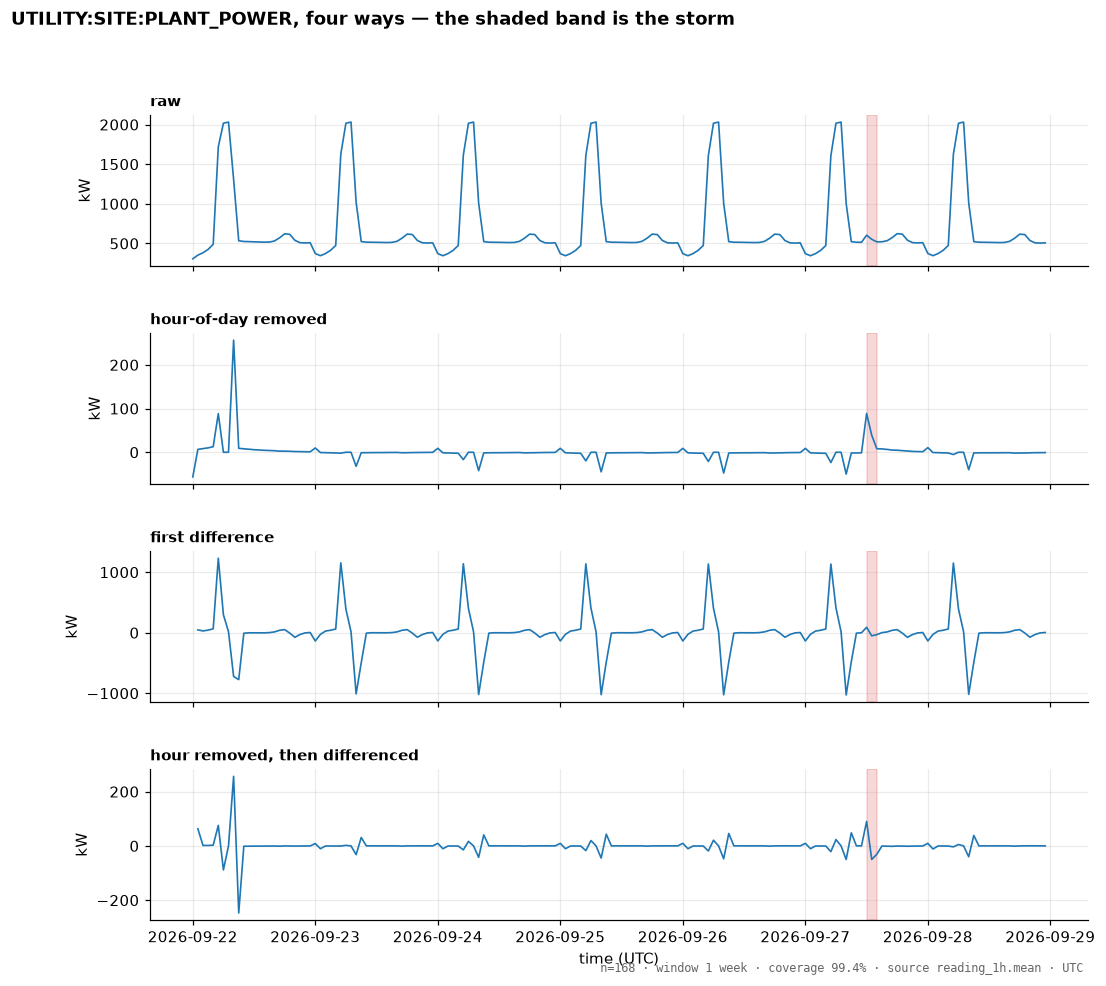

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
for ax, (name, x) in zip(
    axes,
    [
        ("raw", transforms["raw"]),
        ("hour-of-day removed", transforms["hour-of-day removed"]),
        ("first difference", transforms["first difference"]),
        (
            "hour removed, then differenced",
            transforms["hour removed, then differenced"],
        ),
    ],
    strict=True,
):
    ax.plot(x.index, x.values, linewidth=1.1)
    ax.axvspan(storm_start, storm_end, color="#d62728", alpha=0.18)
    ax.set_ylabel("kW")
    ax.set_title(name, loc="left", fontsize=10, fontweight="bold")
axes[-1].set_xlabel("time (UTC)")
fig.suptitle(
    "UTILITY:SITE:PLANT_POWER, four ways — the shaded band is the storm",
    x=0.01,
    ha="left",
    fontweight="bold",
)
stamp(
    axes[-1],
    transforms["raw"].dropna(),
    window="1 week",
    source="reading_1h.mean",
    expected_s=3600,
)
fig.subplots_adjust(hspace=0.45)
save(fig, "06_transforms")

The four panels are the table drawn. The second is flat noise with one excursion at the
shaded storm; the third still has the day in it; the fourth swings wider than the second,
which is the variance going *up*. A transformation that makes a plot busier has done
something wrong.

## The same treatment on three signals, and what is left

In [5]:
def residual_after_the_clock(series):
    calm = series[
        (series.index < storm_start)
        | (series.index >= storm_end + pd.Timedelta(hours=3))
    ]
    prof = calm.groupby(calm.index.hour).mean()
    return series - series.index.hour.map(prof).to_numpy()


rows = []
for sig in (POWER, "INFLUENT:LIFT:FLOW", "AERATION:AHU-1:AIR_FLOW"):
    s = hourly[sig]
    r = residual_after_the_clock(s)
    z = (r - r.mean()) / r.std()
    inside = z[(z.index >= storm_start) & (z.index < storm_end)]
    rows.append(
        {
            "signal": sig,
            "variance before": s.var(),
            "variance after": r.var(),
            "share removed": 1 - r.var() / s.var(),
            "storm hour 1, z": inside.iloc[0],
            "storm hour 2, z": inside.iloc[1],
        }
    )
print(
    pd.DataFrame(rows)
    .set_index("signal")
    .round(
        {
            "variance before": 0,
            "variance after": 0,
            "share removed": 3,
            "storm hour 1, z": 1,
            "storm hour 2, z": 1,
        }
    )
    .to_string()
)

                          variance before  variance after  share removed  storm hour 1, z  storm hour 2, z
signal                                                                                                    
UTILITY:SITE:PLANT_POWER         227051.0           602.0          0.997              3.6              1.6
INFLUENT:LIFT:FLOW               167200.0         30721.0          0.816             12.1              4.2
AERATION:AHU-1:AIR_FLOW        44394239.0        110742.0          0.998             -0.3              0.3


```output
                          variance before  variance after  share removed  storm hour 1, z  storm hour 2, z
signal                                                                                                    
UTILITY:SITE:PLANT_POWER         227051.0           602.0          0.997              3.6              1.6
INFLUENT:LIFT:FLOW               167200.0         30721.0          0.816             12.1              4.2
AERATION:AHU-1:AIR_FLOW        44394239.0        110742.0          0.998             -0.3              0.3
```

Repeat the hour-of-day treatment on three signals. It removes **99.7 %** of plant power's
variance and **99.8 %** of air flow's, but only **81.6 %** of the lift-station flow's —
and that is informative, because what is left of the flow is the storm. In the first
storm hour the flow's residual is **12.1** standard deviations from zero, the power's is
**3.6**, and the air flow's is **-0.3**.

Two things follow, and the second sets up notebook 11. First, once the clock is
subtracted, an event that was one wobble among many in the raw series stands out by a
margin no threshold could miss; that is how notebook 09 will find it. Second, the storm
reaches the flow meter and the pumps and **does not reach the blowers**. The air supply
carries on following its daily profile while the water changes underneath it.

In [6]:
air = hourly["AERATION:AHU-1:AIR_FLOW"]
pairs = pd.DataFrame(
    {
        "raw": pd.concat([power, air], axis=1).corr().iloc[0, 1],
        "hour removed": pd.concat(
            [residual_after_the_clock(power), residual_after_the_clock(air)], axis=1
        )
        .corr()
        .iloc[0, 1],
        "first difference": pd.concat([power.diff(), air.diff()], axis=1)
        .corr()
        .iloc[0, 1],
    },
    index=["plant power vs air flow"],
).T
print(pairs.round(4).to_string())

                  plant power vs air flow
raw                                0.9997
hour removed                       0.9489
first difference                   0.9995


```output
                  plant power vs air flow
raw                                0.9997
hour removed                       0.9489
first difference                   0.9995
```

One consequence for the correlations of notebook 01. Plant power and air flow correlate
**0.9997** raw and **0.9995** after a first difference — which, as the table showed,
did not remove the cycle. With the hour of day removed the correlation is **0.9489**.

Nothing has gone wrong. The coupling is real, and in the storm hours it *breaks*: the
pumps draw more power and the blowers do not follow. The two series agree everywhere
except where something unusual happens, which is the only place a correlation is worth
having.

## Which transformation for which purpose

| you are about to… | do this first | because | watch for |
|---|---|---|---|
| put an interval on a **level** (notebook 05) | nothing — use whole days as the unit | the cycle is signal, not noise, and it averages out over a day | a block shorter than the cycle |
| flag an **anomaly** (notebook 09) | remove the hour-of-day profile | residuals are comparable across the day | build the profile *without* the event, or it absorbs it |
| date a **change point** (notebook 10) | remove the profile; do **not** difference | a step in the level is still a step in the residual | differencing turns a step into a one-hour spike |
| **validate a forecast** (notebook 08) | use a seasonal baseline (24 h) | it is the bar the model has to clear | a random split hides the cycle from the test set |
| **correlate** two signals (notebook 01) | remove the profile from both | otherwise they share a clock | the pair that survives may still break during an event |
| anything, having already cleaned | **stop** | a second difference lifts variance and forces lag-one to -0.5 | the Dickey-Fuller statistic will look excellent |

## Takeaways

- **A stationarity test is not a seasonality test.** The raw hourly power scores
  **-4.96**, past the 1 % line at -3.43, with a daily autocorrelation of **0.998**.
- **A first difference does not remove a cycle.** It leaves an autocorrelation of
  **0.994** at a day. Remove the hour-of-day profile or take a seasonal difference.
- **99.7 % of plant power's variance is the clock**, and removing it leaves a
  lag-one autocorrelation of **0.081**.
- **Over-differencing has a signature**: variance up (601.9 to **1095.2**) and lag-one
  autocorrelation at **-0.474**. If it went the wrong way, stop.
- **Subtract the clock, then look for the event.** The storm is **12.1** standard
  deviations in the flow's residual and **-0.3** in the air flow's: it reaches the
  pumps and not the blowers.

## Exercises

1. **Build the profile with the storm in.** Repeat the table computing the hour-of-day
   profile from all 168 hours. What happens to the storm-hour residuals, and why is that
   the reason the profile was built storm-free?
2. **Choose the difference lag.** The cycle is 24 hours. Take seasonal differences at 12,
   23, 24 and 25 hours and compare the daily autocorrelation. Which is best, and what does
   the answer say about how exact the cycle is?
3. **Do it at one minute.** Repeat the analysis on the one-minute means. What replaces
   the 24-hour lag, how many points does a seasonal difference cost, and does the
   over-differencing signature change?
4. **A better test.** The Dickey-Fuller regression here has no seasonal terms. Add
   twenty-three hour-of-day dummies to it and see what happens to the statistic on the
   raw series. What has the test learned?

---

**Next:** [07 — What are you estimating](07-what-are-you-estimating.ipynb) ·
**Back to the series** [README](README.md) ·
**Previous:** [05 — Autocorrelation](05-autocorrelation.ipynb)